# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [2]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [3]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/test_relu.py"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: /Users/hong-yoonki/Desktop/krafton/vscode/week13/week13-team-07-mnist-lab
실행 명령: /opt/anaconda3/bin/python -m pytest tests/test_relu.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.5, pytest-7.4.0, pluggy-1.0.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/hong-yoonki/Desktop/krafton/vscode/week13/week13-team-07-mnist-lab
plugins: anyio-4.12.1
collecting ... collected 3 items

tests/test_relu.py::TestReLU::test_relu_forward_positive PASSED          [ 33%]
tests/test_relu.py::TestReLU::test_relu_forward_negative_zero PASSED     [ 66%]
tests/test_relu.py::TestReLU::test_relu_backward PASSED                  [100%]

============================== 3 passed in 0.06s ===============================


선택한 테스트를 통과했습니다.


## 4. 모델·옵티마이저 생성 및 학습

In [62]:
from network import NeuralNetwork
from optimizers import Adam
from training import train
from optimizers import SGD
from datetime import datetime

train_start_time = datetime.now()

batchnorm = False
dropout = False
dropout_rt = None


model = NeuralNetwork(use_batchnorm=batchnorm, use_dropout=dropout)  # BatchNorm, Dropout 필수
optimizer = Adam(lr=0.026677926407289915)
# optimizer = SGD(lr=0.001)

epochs = 20
bat_size = 128

loss_history = train(model, optimizer, x_train, y_train, epochs=epochs, batch_size=bat_size)

## 5. 평가 및 손실 커브

Train Accuracy: 99.48%
Test Accuracy: 96.01%
Total Params: 535,818


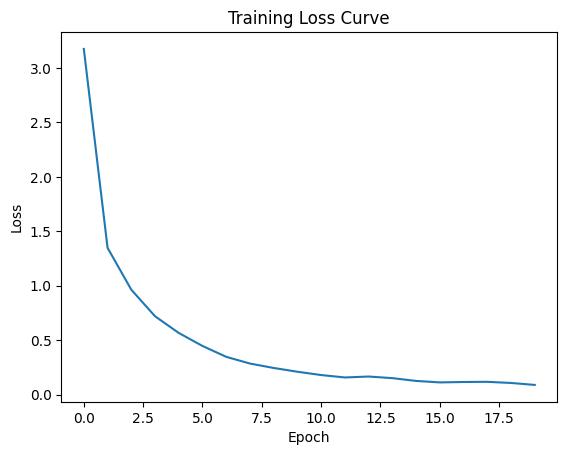

In [63]:
from training import evaluate, plot_loss_history

# acc, n_params = evaluate(model, x_test, y_test)

final_test_acc, n_params = evaluate(model, x_test, y_test)
final_train_acc, _ = evaluate(model, x_train, y_train)

# print(f'Test Accuracy: {acc:.2f}%')
print(f"Train Accuracy: {final_train_acc:.2f}%")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

In [65]:
# 모델 저장

import os
import pickle
import platform
from datetime import datetime

os.makedirs("saved_models", exist_ok=True)

current_epoch = len(loss_history)
model_name = "20ep-adam-mj"  # 원하는 이름으로 변경 가능

# 아래 값들은 학습 셀에서 실제로 사용한 값과 맞춰주기
hidden_dims = [512, 256]
activation = "ReLU"
optimizer_name = type(optimizer).__name__
learning_rate = optimizer.lr
batch_size = bat_size
use_batchnorm = batchnorm
use_dropout = dropout
dropout_ratio = dropout_rt
weight_init = "He"

# 학습 시간
# 학습 시작 전에 train_start_time = datetime.now() 같은 방식으로 기록해두었다고 가정
# 아직 없다면 우선 None으로 저장 가능
train_start_time_str = train_start_time.isoformat(timespec="seconds") if "train_start_time" in globals() else None
train_end_time = datetime.now()
train_end_time_str = train_end_time.isoformat(timespec="seconds")
training_time_sec = (train_end_time - train_start_time).total_seconds() if "train_start_time" in globals() else None

total_params = sum(p.size for p in model.params.values())

checkpoint = {
    "model_params": {k: v.copy() for k, v in model.params.items()},
    "optimizer_state": {
        "m": {k: v.copy() for k, v in optimizer.m.items()},
        "v": {k: v.copy() for k, v in optimizer.v.items()},
        "t": optimizer.t,
        "lr": optimizer.lr,
    },
    "model_structure": {
        "num_hidden_layers": len(hidden_dims),
        "hidden_dims": hidden_dims,
        "input_dim": 784,
        "output_dim": 10,
        "activation": activation,
    },
    "training_config": {
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "epochs": current_epoch,
        "batch_size": batch_size,
    },
    "regularization": {
        "use_batchnorm": use_batchnorm,
        "use_dropout": use_dropout,
        "dropout_ratio": dropout_ratio,
    },
    "initialization": {
        "weight_init": weight_init,
    },
    "train_state": {
        "epoch": current_epoch,
        "loss_history": list(loss_history),
    },
    "results": {
        "final_train_loss": float(loss_history[-1]) if len(loss_history) > 0 else None,
        "final_train_acc": float(final_train_acc),
        "final_test_acc": float(final_test_acc),
        "total_params": int(total_params),
    },
    "runtime": {
        "environment": "colab" if "google.colab" in str(type(get_ipython())) else "local",
        "platform": platform.platform(),
        "train_start_time": train_start_time_str,
        "train_end_time": train_end_time_str,
        "training_time_sec": training_time_sec,
    },
    "meta": {
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    },
}

checkpoint_path = f"saved_models/{model_name}.pkl"

with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint, f)

print(f"saved: {checkpoint_path}")

saved: saved_models/20ep-adam-mj.pkl


In [ ]:
# 저장된 모델 불러오기

import pickle
from network import NeuralNetwork
from optimizers import Adam, SGD

checkpoint_path = "saved_models/1500ep-mj.pkl" # 어느 모델을 불러올지 지정

with open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

regularization = checkpoint.get("regularization", {})
training_config = checkpoint.get("training_config", {})
results = checkpoint.get("results", {})

use_batchnorm = regularization.get("use_batchnorm", False)
use_dropout = regularization.get("use_dropout", False)
dropout_ratio = regularization.get("dropout_ratio", None)

model = NeuralNetwork(
    use_batchnorm=use_batchnorm,
    use_dropout=use_dropout,
    dropout_ratio=dropout_ratio,
)

optimizer_name = training_config.get("optimizer", "Adam")
learning_rate = training_config.get("learning_rate", checkpoint["optimizer_state"]["lr"])

if optimizer_name == "Adam":
    optimizer = Adam(lr=learning_rate)
elif optimizer_name == "SGD":
    optimizer = SGD(lr=learning_rate)
else:
    raise ValueError(f"지원하지 않는 optimizer입니다: {optimizer_name}")

# 핵심: params dict를 통째로 바꾸지 말고, 기존 배열에 값만 복사
for key in model.params:
    model.params[key][...] = checkpoint["model_params"][key]

# optimizer 상태 복원
if optimizer_name == "Adam":
    optimizer.m = {k: v.copy() for k, v in checkpoint["optimizer_state"]["m"].items()}
    optimizer.v = {k: v.copy() for k, v in checkpoint["optimizer_state"]["v"].items()}
    optimizer

In [ ]:
# 이어서 학습

additional_epochs = 100
new_loss_history = train(model, optimizer, x_train, y_train, epochs=additional_epochs, batch_size=100)

loss_history.extend(new_loss_history)
current_epoch += additional_epochs

In [73]:
# 저장된 모델들 확인

import os
import glob
import pickle
import pandas as pd

model_files = sorted(glob.glob("saved_models/*.pkl"))
rows = []

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    model_structure = checkpoint.get("model_structure", {})
    training_config = checkpoint.get("training_config", {})
    regularization = checkpoint.get("regularization", {})
    initialization = checkpoint.get("initialization", {})
    results = checkpoint.get("results", {})
    runtime = checkpoint.get("runtime", {})
    meta = checkpoint.get("meta", {})
    train_state = checkpoint.get("train_state", {})
    optimizer_state = checkpoint.get("optimizer_state", {})

    rows.append({
        "file_name": os.path.basename(path),

        # 모델 구조
        "num_hidden_layers": model_structure.get("num_hidden_layers"),
        "hidden_dims": str(model_structure.get("hidden_dims")),
        "input_dim": model_structure.get("input_dim"),
        "output_dim": model_structure.get("output_dim"),
        "activation": model_structure.get("activation"),

        # 학습 설정
        "optimizer": training_config.get("optimizer"),
        "learning_rate": training_config.get("learning_rate"),
        "epochs": training_config.get("epochs"),
        "batch_size": training_config.get("batch_size"),

        # 정규화·규제
        "use_batchnorm": regularization.get("use_batchnorm"),
        "use_dropout": regularization.get("use_dropout"),
        "dropout_ratio": regularization.get("dropout_ratio"),

        # 초기화
        "weight_init": initialization.get("weight_init"),

        # 결과
        "final_train_loss": results.get("final_train_loss"),
        "final_train_acc": results.get("final_train_acc"),
        "final_test_acc": results.get("final_test_acc"),
        "total_params": results.get("total_params"),

        # 학습 상태
        "saved_epoch": train_state.get("epoch"),
        "loss_history_len": len(train_state.get("loss_history", [])),

        # optimizer 상태
        "optimizer_lr": optimizer_state.get("lr"),
        "optimizer_step_t": optimizer_state.get("t"),

        # 시간 / 실행 환경
        "environment": runtime.get("environment"),
        "platform": runtime.get("platform"),
        "training_time_sec": runtime.get("training_time_sec"),
        "train_start_time": runtime.get("train_start_time"),
        "train_end_time": runtime.get("train_end_time"),

        # 메타
        "saved_at": meta.get("saved_at"),
    })

df = pd.DataFrame(rows)

# 보기 좋게 숫자 컬럼 정리
float_cols = [
    "learning_rate",
    "optimizer_lr",
    "final_train_loss",
    "final_train_acc",
    "final_test_acc",
    "training_time_sec",
]

for col in float_cols:
    if col in df.columns:
        df[col] = df[col].round(4)

# 전체 표
display(df)

# # 핵심 비교용 표
# summary_cols = [
#     "file_name",
#     "optimizer",
#     "learning_rate",
#     "epochs",
#     "batch_size",
#     "use_batchnorm",
#     "use_dropout",
#     "dropout_ratio",
#     "weight_init",
#     "final_train_loss",
#     "final_train_acc",
#     "final_test_acc",
#     "total_params",
#     "training_time_sec",
#     "saved_at",
# ]

# display(df[summary_cols])

,file_name,num_hidden_layers,hidden_dims,input_dim,output_dim,activation,optimizer,learning_rate,epochs,batch_size,...,saved_epoch,loss_history_len,optimizer_lr,optimizer_step_t,environment,platform,training_time_sec,train_start_time,train_end_time,saved_at
0,1500ep-mj.pkl,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1500,1500,0.0010,900000,NaN,NaN,NaN,NaN,NaN,2026-05-26T13:18:54
1,20ep-adam-mj.pkl,2.0,"[512, 256]",784.0,10.0,ReLU,Adam,0.0267,20.0,128.0,...,20,20,0.0267,9380,local,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,351.4041,2026-05-26T16:15:39,2026-05-26T16:21:31,2026-05-26T16:21:31
2,64ep-yk.pkl,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1500,64,0.0267,38400,NaN,NaN,NaN,NaN,NaN,2026-05-26T13:35:31


In [74]:
# 제외할 파일명 지정

import glob
import os

excluded_files = {"1500ep-mj.pkl"}

model_files = [
    path for path in sorted(glob.glob("saved_models/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

print([os.path.basename(path) for path in model_files])

['20ep-adam-mj.pkl', '64ep-yk.pkl']


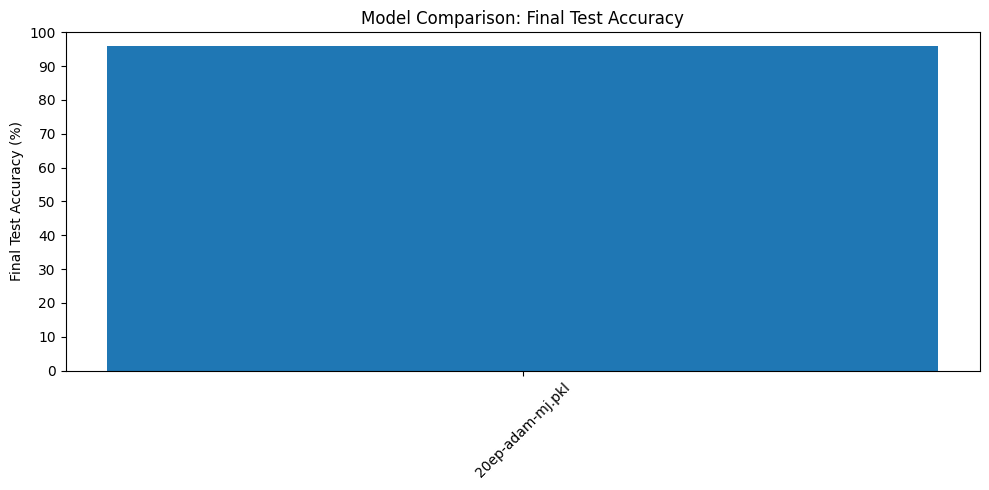

In [76]:
# 최종 테스트 정확도 막대그래프

import matplotlib.pyplot as plt

plot_df = df.dropna(subset=["final_test_acc"]).copy()
plot_df = plot_df[~plot_df["file_name"].isin(excluded_files)]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["file_name"], plot_df["final_test_acc"])
plt.xticks(rotation=45)
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)
plt.ylabel("Final Test Accuracy (%)")
plt.title("Model Comparison: Final Test Accuracy")
plt.tight_layout()
plt.show()

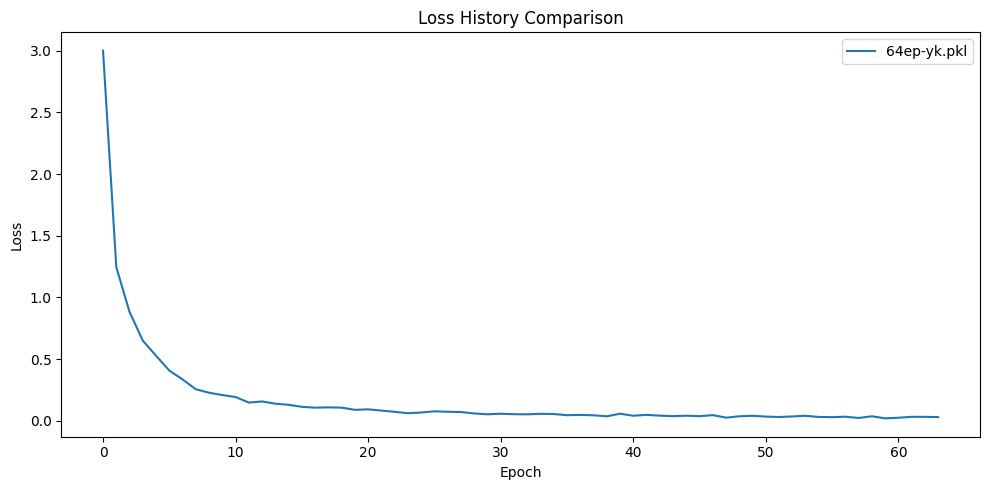

In [49]:
# 최종 loss 막대그래프

import os
import glob
import pickle
import matplotlib.pyplot as plt

model_files = [
    path for path in sorted(glob.glob("saved_models/*.pkl"))
    if os.path.basename(path) not in excluded_files
]

plt.figure(figsize=(10, 5))

for path in model_files:
    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    loss_history = checkpoint.get("train_state", {}).get("loss_history", [])
    if len(loss_history) > 0:
        plt.plot(loss_history, label=os.path.basename(path))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History Comparison")
plt.legend()
plt.tight_layout()
plt.show()